<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.9}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Alumna:} & Morales Ramirez Mariagne Quetzaltzin \\[6pt]
\textbf{Fecha de realización:} & 03/03/2026
\end{array}

</center>

https://www.youtube.com/watch?v=QJjM7EKDRuc&list=PLDXvhsYB9YPx4scpHhkzzcwCEsYdV4ttl

En este ejemplo, el programa permite a un jugador humano jugar contra la inteligencia artificial (IA) que utiliza el algoritmo Minimax. Puedes ajustar el ejemplo para adaptarlo a tu necesidad específica o probarlo tal como está con el juego del tic-tac-toe.

In [ ]:
import math

def imprimir_tablero(tablero):
    """Imprime el tablero de forma sencilla."""
    for fila in tablero:
        print(" ".join(fila))
    print()

def es_tablero_lleno(tablero):
    """Devuelve True si ya no existen espacios vacíos."""
    for fila in tablero:
        if " " in fila:
            return False
    return True

def evaluar_estado(tablero):
    """
    Evalúa el estado actual del juego:
        1  -> gana X
       -1  -> gana O
        0  -> empate
        None -> el juego todavía no termina
    """
    ganador = None

    # Revisar filas
    for fila in tablero:
        if fila.count("X") == 3:
            ganador = "X"
        elif fila.count("O") == 3:
            ganador = "O"

    # Revisar columnas
    for col in range(3):
        if tablero[0][col] == tablero[1][col] == tablero[2][col] and tablero[0][col] != " ":
            ganador = tablero[0][col]

    # Revisar diagonales
    if tablero[0][0] == tablero[1][1] == tablero[2][2] and tablero[0][0] != " ":
        ganador = tablero[0][0]

    if tablero[0][2] == tablero[1][1] == tablero[2][0] and tablero[0][2] != " ":
        ganador = tablero[0][2]

    if ganador == "X":
        return 1
    elif ganador == "O":
        return -1
    elif es_tablero_lleno(tablero):
        return 0
    else:
        return None


def minimax(tablero, profundidad, es_maximizando):
    """
    Algoritmo Minimax.

    X es el jugador maximizador.
    O es el jugador minimizador.
    """
    estado_actual = evaluar_estado(tablero)

    # Caso base de la recursión:
    # si ya existe ganador o empate, se devuelve su utilidad.
    if estado_actual is not None:
        return estado_actual

    if es_maximizando:
        mejor_valor = -math.inf

        for i in range(3):
            for j in range(3):
                if tablero[i][j] == " ":
                    tablero[i][j] = "X"

                    valor = minimax(
                        tablero,
                        profundidad + 1,
                        False
                    )

                    # Backtracking: deshacer la jugada simulada
                    tablero[i][j] = " "

                    mejor_valor = max(mejor_valor, valor)

        return mejor_valor

    else:
        mejor_valor = math.inf

        for i in range(3):
            for j in range(3):
                if tablero[i][j] == " ":
                    tablero[i][j] = "O"

                    valor = minimax(
                        tablero,
                        profundidad + 1,
                        True
                    )

                    # Backtracking
                    tablero[i][j] = " "

                    mejor_valor = min(mejor_valor, valor)

        return mejor_valor


def mejor_movimiento_ia(tablero):
    """
    La IA juega con O.

    Como O es el jugador minimizador, debe elegir
    el movimiento con el MENOR valor Minimax.
    """
    mejor_valor = math.inf
    mejor_mov = None

    for i in range(3):
        for j in range(3):
            if tablero[i][j] == " ":

                # Simular movimiento de O
                tablero[i][j] = "O"

                # Después de O juega X, que es maximizador
                valor = minimax(tablero, 0, True)

                # Deshacer movimiento
                tablero[i][j] = " "

                if valor < mejor_valor:
                    mejor_valor = valor
                    mejor_mov = (i, j)

    return mejor_mov


# -------------------------------
# Juego: humano (X) contra IA (O)
# -------------------------------

tablero_inicial = [
    [" ", " ", " "],
    [" ", " ", " "],
    [" ", " ", " "]
]

turno = "X"

while evaluar_estado(tablero_inicial) is None:

    imprimir_tablero(tablero_inicial)

    if turno == "X":
        try:
            fila, col = map(
                int,
                input(
                    "Turno de X. Ingrese fila y columna "
                    "(0, 1 o 2) separadas por espacio: "
                ).split()
            )

            if not (0 <= fila <= 2 and 0 <= col <= 2):
                print("Coordenadas fuera del tablero. Intenta de nuevo.\n")
                continue

            if tablero_inicial[fila][col] == " ":
                tablero_inicial[fila][col] = "X"
            else:
                print("Casilla ocupada. Intenta de nuevo.\n")
                continue

        except ValueError:
            print("Entrada inválida. Escribe dos números separados por espacio.\n")
            continue

    else:
        print("Turno de O (IA)")

        movimiento = mejor_movimiento_ia(tablero_inicial)

        if movimiento is not None:
            fila, col = movimiento
            tablero_inicial[fila][col] = "O"

    turno = "O" if turno == "X" else "X"


imprimir_tablero(tablero_inicial)

resultado = evaluar_estado(tablero_inicial)

if resultado == 1:
    print("¡X gana!")
elif resultado == -1:
    print("¡O gana!")
else:
    print("¡Empate!")


# Ejercicio adicional:


1. Interfaz de Usuario "ASCII Art" (Nivel: Creativo)
El print actual es muy básico.

Desafío: Mejorar la visualización del tablero usando caracteres especiales para que se vea más profesional (usando bordes como |, -, +).

|  

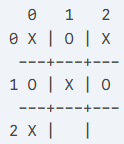

## Solución del ejercicio adicional

Para mejorar la interfaz se agregan bordes y también los índices de las filas y columnas.  
Esto facilita que el jugador identifique las coordenadas que debe escribir.

El resultado se verá aproximadamente así:

```text
    0   1   2
  +---+---+---+
0 | X | O |   |
  +---+---+---+
1 |   | X |   |
  +---+---+---+
2 | O |   | X |
  +---+---+---+
```


In [ ]:
def imprimir_tablero_ascii(tablero):
    """Muestra el tablero utilizando bordes en ASCII."""
    print()
    print("    0   1   2")
    print("  +---+---+---+")

    for i, fila in enumerate(tablero):
        print(
            f"{i} | {fila[0]} | {fila[1]} | {fila[2]} |"
        )
        print("  +---+---+---+")

    print()


# Ejemplo de visualización
tablero_ejemplo = [
    ["X", "O", " "],
    [" ", "X", " "],
    ["O", " ", "X"]
]

imprimir_tablero_ascii(tablero_ejemplo)


# Conclusiones finales del estudiante

En esta práctica se implementó el algoritmo **Minimax** mediante el juego de Tic-Tac-Toe.  
El algoritmo analiza los posibles estados futuros del tablero suponiendo que ambos jugadores toman decisiones óptimas.

Se observó que el jugador **X** actúa como maximizador, buscando estados con valor `1`, mientras que el jugador **O** actúa como minimizador, buscando estados con valor `-1`. La función recursiva explora los movimientos posibles y utiliza *backtracking* para colocar temporalmente una ficha, evaluar sus consecuencias y después restaurar el tablero.

También se mejoró la interfaz del juego mediante una representación en ASCII, agregando bordes e índices para filas y columnas. Esto permite visualizar mejor el tablero y facilita la interacción con el usuario.

La práctica permitió comprender que Minimax no elige una jugada únicamente por su efecto inmediato, sino que considera las posibles respuestas del adversario antes de seleccionar un movimiento.


<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>